In [1]:
!pip install pandas faker numpy scikit-learn --quiet


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
from faker import Faker
import random
from datetime import datetime, timedelta
from sklearn.linear_model import LinearRegression

fake = Faker('ru_RU')

# Data Sampling

In [3]:
NUM_EMPLOYEES = 200
START_DATE = datetime.now() - timedelta(days=365)
END_DATE = datetime.now()

ARCHETYPES = {
    'workaholic': {'share': 0.15, 'burnout_risk': 1},
    'stagnating': {'share': 0.15, 'burnout_risk': 1},
    'balanced': {'share': 0.50, 'burnout_risk': 0},
    'newbie': {'share': 0.20, 'burnout_risk': 0},
}

TOPICS = {
    'workaholic': ['дедлайн', 'переработки', 'высокая нагрузка', 'успех проекта'],
    'stagnating': ['скучно', 'рутина', 'нет развития', 'одно и то же'],
    'balanced': ['интересная задача', 'команда', 'баланс', 'хороший результат'],
    'newbie': ['сложно', 'обучение', 'помощь коллег', 'разобрался']
}

In [4]:
def create_employees(n):
    employees_data = []
    archetype_list = []
    for archetype, props in ARCHETYPES.items():
        count = int(n * props['share'])
        archetype_list.extend([archetype] * count)
    
    while len(archetype_list) < n:
        archetype_list.append('balanced')
    random.shuffle(archetype_list)

    for i in range(n):
        archetype = archetype_list[i]
        tenure = random.randint(3, 120) if archetype != 'newbie' else random.randint(1, 12)
        
        employees_data.append({
            'employee_id': 1000 + i,
            'age': random.randint(22, 55),
            'gender': random.choice(['Мужской', 'Женский']),
            'tenure_months': tenure,
            'archetype': archetype,
            'burnout_risk': ARCHETYPES[archetype]['burnout_risk']
        })
    return pd.DataFrame(employees_data)

employees_df = create_employees(NUM_EMPLOYEES)
print("Создан датафрейм сотрудников:")
display(employees_df.head())
print(f"\nРаспределение по архетипам:\n{employees_df['archetype'].value_counts()}")

Создан датафрейм сотрудников:


,employee_id,age,gender,tenure_months,archetype,burnout_risk
0,1000,37,Женский,107,balanced,0
1,1001,44,Мужской,20,balanced,0
2,1002,48,Мужской,17,balanced,0
3,1003,25,Мужской,46,stagnating,1
4,1004,29,Женский,13,balanced,0



Распределение по архетипам:
archetype
balanced      100
newbie         40
stagnating     30
workaholic     30
Name: count, dtype: int64


In [5]:
def generate_events(employees_df):
    all_events = []
    date_range = pd.date_range(START_DATE, END_DATE)

    for _, emp in employees_df.iterrows():
        emp_id = emp['employee_id']
        archetype = emp['archetype']
        
        # Индивидуальные параметры для симуляции
        task_prob = 0.5
        sick_prob = 0.005
        vacation_days_left = 14
        
        if archetype == 'workaholic':
            task_prob = 0.8
            sick_prob = 0.002 # Реже болеет, но...
        elif archetype == 'stagnating':
            task_prob = 0.3
            sick_prob = 0.01

        for day in date_range:
            # Симуляция изменения поведения со временем для "выгорающих"
            days_passed_ratio = (day - START_DATE).days / 365.0

            # Задачи
            if random.random() < task_prob and day.weekday() < 5:
                status = 'success'
                overdue = 0
                if archetype == 'workaholic' and random.random() < days_passed_ratio * 0.3: # Вероятность просрочки растет
                    overdue = random.randint(1, 5)
                    status = 'failed'
                all_events.append({'employee_id': emp_id, 'event_type': 'task_completed', 'event_timestamp': day, 'event_details': {'status': status, 'overdue_days': overdue}})

            # Больничные
            if random.random() < sick_prob:
                duration = random.randint(1, 5)
                if archetype == 'workaholic' and days_passed_ratio > 0.5: # Короткие больничные от усталости
                    duration = random.randint(1, 2)
                all_events.append({'employee_id': emp_id, 'event_type': 'sick_leave', 'event_timestamp': day, 'event_details': {'duration_days': duration}})

            # Еженедельные чекины (по пятницам)
            if day.weekday() == 4:
                sentiment = 0.0
                if archetype == 'workaholic':
                    sentiment = 0.5 - 1.5 * days_passed_ratio # Сначала позитив, потом резкий минус
                elif archetype == 'stagnating':
                    sentiment = -0.1 - 0.4 * days_passed_ratio # Стабильно-негативный
                elif archetype == 'balanced':
                    sentiment = np.random.normal(0.4, 0.2)
                elif archetype == 'newbie':
                    sentiment = -0.5 + 1.5 * days_passed_ratio # Сначала сложно, потом позитив
                
                sentiment = np.clip(sentiment, -1.0, 1.0) # Ограничиваем значения
                topics = random.sample(TOPICS[archetype], k=random.randint(1,2))
                all_events.append({'employee_id': emp_id, 'event_type': 'check_in', 'event_timestamp': day, 'event_details': {'sentiment': round(sentiment, 2), 'topics': topics}})
            
            # Отпуск
            if vacation_days_left > 0 and day.month in [7, 8, 12] and random.random() < 0.01:
                 if archetype != 'workaholic' or (archetype == 'workaholic' and random.random() < 0.1): # Трудоголик вряд ли пойдет
                    duration = random.choice([7, 14])
                    all_events.append({'employee_id': emp_id, 'event_type': 'vacation', 'event_timestamp': day, 'event_details': {'duration_days': duration}})
                    vacation_days_left -= duration

    return pd.DataFrame(all_events)


events_df = generate_events(employees_df)
print("Сгенерирован временной ряд событий:")
display(events_df.head())
print(f"\nВсего событий: {len(events_df)}")

Сгенерирован временной ряд событий:


,employee_id,event_type,event_timestamp,event_details
0,1000,task_completed,2024-11-11 19:56:50.498387,"{'status': 'success', 'overdue_days': 0}"
1,1000,task_completed,2024-11-12 19:56:50.498387,"{'status': 'success', 'overdue_days': 0}"
2,1000,task_completed,2024-11-14 19:56:50.498387,"{'status': 'success', 'overdue_days': 0}"
3,1000,check_in,2024-11-15 19:56:50.498387,"{'sentiment': 0.24, 'topics': ['интересная зад..."
4,1000,task_completed,2024-11-21 19:56:50.498387,"{'status': 'success', 'overdue_days': 0}"



Всего событий: 37854


In [6]:
events_df

,employee_id,event_type,event_timestamp,event_details
0,1000,task_completed,2024-11-11 19:56:50.498387,"{'status': 'success', 'overdue_days': 0}"
1,1000,task_completed,2024-11-12 19:56:50.498387,"{'status': 'success', 'overdue_days': 0}"
2,1000,task_completed,2024-11-14 19:56:50.498387,"{'status': 'success', 'overdue_days': 0}"
3,1000,check_in,2024-11-15 19:56:50.498387,"{'sentiment': 0.24, 'topics': ['интересная зад..."
4,1000,task_completed,2024-11-21 19:56:50.498387,"{'status': 'success', 'overdue_days': 0}"
...,...,...,...,...
37849,1199,check_in,2025-10-31 19:56:50.498387,"{'sentiment': -0.49, 'topics': ['нет развития']}"
37850,1199,task_completed,2025-11-05 19:56:50.498387,"{'status': 'success', 'overdue_days': 0}"
37851,1199,task_completed,2025-11-06 19:56:50.498387,"{'status': 'success', 'overdue_days': 0}"
37852,1199,check_in,2025-11-07 19:56:50.498387,"{'sentiment': -0.5, 'topics': ['скучно', 'одно..."


In [8]:
import pandas as pd
import numpy as np
import random
from datetime import datetime

def generate_advanced_employee_data(num_records, start_id):
    """
    Генерирует продвинутые, "зашумленные" и реалистичные данные о сотрудниках,
    чтобы создать более сложную задачу для модели.
    """
    new_data = []
    
    # Добавляем новые архетипы и меняем их веса
    archetypes = ["stable_professional", "new_enthusiast", "at_risk", "burned_out", 
                  "overachiever_under_strain", "coaster"]
    weights = [0.45, 0.10, 0.15, 0.10, 0.10, 0.10] 

    for i in range(num_records):
        employee_id = start_id + i
        archetype = random.choices(archetypes, weights=weights)[0]

        age = np.random.randint(22, 58)
        gender = random.choice(["Мужской", "Женский"])
        
        # Базовые значения по умолчанию
        base_tasks_completed = 15
        base_tasks_failed = 1
        base_sentiment = 0.4
        base_sick_days = 1.0
        
        if archetype == "burned_out":
            burnout_risk = 1
            tenure_months = np.random.randint(24, 120)
            days_since_last_vacation = np.random.randint(300, 700)
            
            base_tasks_completed = np.random.normal(10, 3) # Среднее 10, но могут быть всплески
            base_tasks_failed = np.random.normal(5, 2)
            base_sentiment = np.random.normal(-0.7, 0.15)
            base_sick_days = np.random.normal(5, 2)
            sentiment_trend_last_90d = -1.0

        elif archetype == "at_risk":
            burnout_risk = 0
            tenure_months = np.random.randint(18, 90)
            days_since_last_vacation = np.random.randint(200, 400)

            base_tasks_completed = np.random.normal(14, 4)
            base_tasks_failed = np.random.normal(2.5, 1)
            base_sentiment = np.random.normal(-0.1, 0.2)
            base_sick_days = np.random.normal(2, 1.5)
            sentiment_trend_last_90d = -1.0
            
        elif archetype == "new_enthusiast":
            burnout_risk = 0
            tenure_months = np.random.randint(1, 12)
            days_since_last_vacation = tenure_months * 30 
            
            base_tasks_completed = np.random.normal(19, 3)
            base_tasks_failed = np.random.normal(0.5, 0.5)
            base_sentiment = np.random.normal(0.8, 0.1)
            base_sick_days = np.random.normal(0.5, 0.5)
            sentiment_trend_last_90d = 1.0

        elif archetype == "overachiever_under_strain":
            burnout_risk = 0 # Ключевой момент! Они еще не выгорели.
            tenure_months = np.random.randint(12, 60)
            days_since_last_vacation = np.random.randint(180, 500)
            
            base_tasks_completed = np.random.normal(22, 4) # Очень продуктивны
            base_tasks_failed = np.random.normal(1.5, 1) # Но уже начинают ошибаться
            base_sentiment = np.random.normal(0.1, 0.2) # Настроение уже не на высоте
            base_sick_days = np.random.normal(1.5, 1) # Появляются "сигнальные" больничные
            sentiment_trend_last_90d = -1.0 # Тренд отрицательный

        elif archetype == "coaster":
            burnout_risk = 0
            tenure_months = np.random.randint(48, 180)
            days_since_last_vacation = np.random.randint(100, 400)
            
            base_tasks_completed = np.random.normal(10, 2) # Производительность низкая
            base_tasks_failed = np.random.normal(0.5, 0.5) # Но и не ошибаются, т.к. не рискуют
            base_sentiment = np.random.normal(0.1, 0.1) # Настроение ровное, нейтральное
            base_sick_days = np.random.normal(1, 1)
            sentiment_trend_last_90d = 0.0
            
        else: # stable_professional
            burnout_risk = 0
            tenure_months = np.random.randint(12, 150)
            days_since_last_vacation = np.random.randint(20, 365)
            
            base_tasks_completed = np.random.normal(17, 3)
            base_tasks_failed = np.random.normal(0.7, 0.5)
            base_sentiment = np.random.normal(0.5, 0.15)
            base_sick_days = np.random.normal(1, 1)
            sentiment_trend_last_90d = 0.0

        # --- Генерация метрик с добавлением шума ---
        
        # 30 дней
        tasks_completed_30d = max(0, int(base_tasks_completed + np.random.normal(0, 2)))
        tasks_failed_30d = max(0, int(base_tasks_failed + np.random.normal(0, 1)))
        total_sick_days_30d = max(0.0, base_sick_days + np.random.normal(0, 1))
        avg_sentiment_30d = np.clip(base_sentiment + np.random.normal(0, 0.1), -1.0, 1.0)

        # 90 и 365 дней (с вариативностью)
        tasks_completed_90d = tasks_completed_30d * np.random.normal(3, 0.5)
        tasks_failed_90d = tasks_failed_30d * np.random.normal(3, 0.7)
        total_sick_days_90d = total_sick_days_30d * np.random.normal(2.5, 0.8)
        avg_sentiment_90d = avg_sentiment_30d * np.random.normal(1.0, 0.1)

        tasks_completed_365d = tasks_completed_90d * np.random.normal(4, 0.5)
        tasks_failed_365d = tasks_failed_90d * np.random.normal(4, 0.8)
        total_sick_days_365d = total_sick_days_90d * np.random.normal(3, 1)
        avg_sentiment_365d = avg_sentiment_90d * np.random.normal(1.0, 0.1)

        sick_leave_count_last_30d = 1.0 if total_sick_days_30d >= 1 else 0.0
        short_sick_leaves_count_last_30d = 1.0 if 1 <= total_sick_days_30d <= 2 else 0.0
        
        new_data.append({
            "employee_id": employee_id, "age": age, "gender": gender, "tenure_months": tenure_months,
            "burnout_risk": burnout_risk,
            "tasks_completed_last_30d": int(tasks_completed_30d),
            "tasks_failed_last_30d": int(tasks_failed_30d),
            "sick_leave_count_last_30d": sick_leave_count_last_30d,
            "short_sick_leaves_count_last_30d": short_sick_leaves_count_last_30d,
            "total_sick_days_last_30d": round(total_sick_days_30d, 1),
            "avg_sentiment_last_30d": round(avg_sentiment_30d, 4),
            "tasks_completed_last_90d": abs(int(tasks_completed_90d)),
            "tasks_failed_last_90d": abs(int(tasks_failed_90d)),
            "sick_leave_count_last_90d": max(0, np.ceil(total_sick_days_90d / 4)),
            "short_sick_leaves_count_last_90d": max(0, np.ceil(total_sick_days_90d / 4 * np.random.uniform(0.3, 0.7))),
            "total_sick_days_last_90d": abs(round(total_sick_days_90d, 1)),
            "avg_sentiment_last_90d": round(np.clip(avg_sentiment_90d, -1, 1), 4),
            "tasks_completed_last_365d": abs(int(tasks_completed_365d)),
            "tasks_failed_last_365d": abs(int(tasks_failed_365d)),
            "sick_leave_count_last_365d": max(0, np.ceil(total_sick_days_365d / 5)),
            "short_sick_leaves_count_last_365d": max(0, np.ceil(total_sick_days_365d / 5 * np.random.uniform(0.3, 0.7))),
            "total_sick_days_last_365d": abs(round(total_sick_days_365d, 1)),
            "avg_sentiment_last_365d": round(np.clip(avg_sentiment_365d, -1, 1), 4),
            "days_since_last_vacation": int(days_since_last_vacation),
            "sentiment_trend_last_90d": sentiment_trend_last_90d
        })
    
    return pd.DataFrame(new_data)

if __name__ == "__main__":
    try:
        original_df = pd.read_csv("employee_burnout_dataset.csv")
        print(f"Исходный датасет загружен. В нем {len(original_df)} записей.")
        
        last_id = original_df['employee_id'].max()
        start_id = last_id + 1
        
        NUM_RECORDS_TO_GENERATE = 100000
        
        print(f"Генерация {NUM_RECORDS_TO_GENERATE} новых, более сложных записей...")
        start_time = datetime.now()
        
        new_df = generate_advanced_employee_data(NUM_RECORDS_TO_GENERATE, start_id)
        
        end_time = datetime.now()
        print(f"Генерация завершена за {end_time - start_time}.")
        
        combined_df = pd.concat([original_df, new_df], ignore_index=True)
        
        output_filename = "advanced_employee_burnout_dataset.csv"
        combined_df.to_csv(output_filename, index=False)
        
        print(f"\nГотово! Расширенный датасет сохранен в файл '{output_filename}'.")
        print(f"Новый датасет содержит {len(combined_df)} записей.")

    except FileNotFoundError:
        print("Ошибка: файл 'employee_burnout_dataset.csv' не найден.")
    except Exception as e:
        print(f"Произошла ошибка: {e}")

Исходный датасет загружен. В нем 200 записей.
Генерация 100000 новых, более сложных записей...
Генерация завершена за 0:00:02.653172.

Готово! Расширенный датасет сохранен в файл 'advanced_employee_burnout_dataset.csv'.
Новый датасет содержит 100200 записей.


In [2]:
data = pd.read_csv('/Users/stepansepilov/Desktop/Code/hack/src/notebooks/extended_employee_burnout_dataset.csv')
data

,employee_id,age,gender,tenure_months,burnout_risk,tasks_completed_last_30d,tasks_failed_last_30d,sick_leave_count_last_30d,short_sick_leaves_count_last_30d,total_sick_days_last_30d,...,total_sick_days_last_90d,avg_sentiment_last_90d,tasks_completed_last_365d,tasks_failed_last_365d,sick_leave_count_last_365d,short_sick_leaves_count_last_365d,total_sick_days_last_365d,avg_sentiment_last_365d,days_since_last_vacation,sentiment_trend_last_90d
0,1000,37,Женский,107,0,8,0,0.0,0.0,0.0,...,0.0,0.332308,140,0,1.0,1.0,2.0,0.448654,365.0,0.0
1,1001,44,Мужской,20,0,13,0,0.0,0.0,0.0,...,0.0,0.404615,133,0,1.0,0.0,4.0,0.385769,321.0,0.0
2,1002,48,Мужской,17,0,14,0,0.0,0.0,0.0,...,0.0,0.430769,136,0,2.0,1.0,6.0,0.392308,123.0,0.0
3,1003,25,Мужской,46,1,10,0,0.0,0.0,0.0,...,1.0,-0.449231,79,0,4.0,2.0,11.0,-0.300000,87.0,0.0
4,1004,29,Женский,13,0,15,0,0.0,0.0,0.0,...,1.0,0.377692,147,0,1.0,1.0,1.0,0.401538,84.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100195,101195,54,Женский,107,0,13,0,1.0,1.0,2.0,...,4.7,0.471000,185,0,4.0,3.0,16.3,0.454800,250.0,0.0
100196,101196,57,Женский,48,1,7,3,1.0,0.0,3.0,...,4.6,-0.392900,93,30,3.0,3.0,14.9,-0.385200,310.0,-1.0
100197,101197,42,Женский,72,1,8,4,1.0,0.0,7.0,...,15.2,-0.580500,114,40,11.0,7.0,50.2,-0.583300,372.0,-1.0
100198,101198,46,Мужской,77,1,6,6,1.0,0.0,4.0,...,9.7,-1.040000,86,62,6.0,5.0,25.5,-1.075200,445.0,-1.0


# Model training and getting explanations

In [11]:
!pip install catboost shap scikit-learn matplotlib --quiet


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import catboost
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import shap
import matplotlib.pyplot as plt

/Users/stepansepilov/Desktop/Code/hack/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
# Загружаем датасет
try:
    df = pd.read_csv('/Users/stepansepilov/Desktop/Code/hack/src/notebooks/advanced_employee_burnout_dataset.csv')
except FileNotFoundError:
    print("Ошибка: Файл 'employee_burnout_dataset.csv' не найден. Убедитесь, что вы запустили ноутбук для генерации данных.")

if 'df' in locals():
    print("Датасет успешно загружен. Размер:", df.shape)
    display(df.head())

    X = df.drop(columns=['burnout_risk', 'employee_id'])
    y = df['burnout_risk']

    categorical_features_indices = np.where(X.dtypes == 'object')[0]
    print(f"\nКатегориальные признаки: {X.columns[categorical_features_indices].tolist()}")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )

    print(f"\nРазмер обучающей выборки: {X_train.shape}")
    print(f"Размер тестовой выборки: {X_test.shape}")

Датасет успешно загружен. Размер: (100200, 25)


,employee_id,age,gender,tenure_months,burnout_risk,tasks_completed_last_30d,tasks_failed_last_30d,sick_leave_count_last_30d,short_sick_leaves_count_last_30d,total_sick_days_last_30d,...,total_sick_days_last_90d,avg_sentiment_last_90d,tasks_completed_last_365d,tasks_failed_last_365d,sick_leave_count_last_365d,short_sick_leaves_count_last_365d,total_sick_days_last_365d,avg_sentiment_last_365d,days_since_last_vacation,sentiment_trend_last_90d
0,1000,37,Женский,107,0,8,0,0.0,0.0,0.0,...,0.0,0.332308,140,0,1.0,1.0,2.0,0.448654,365.0,0.0
1,1001,44,Мужской,20,0,13,0,0.0,0.0,0.0,...,0.0,0.404615,133,0,1.0,0.0,4.0,0.385769,321.0,0.0
2,1002,48,Мужской,17,0,14,0,0.0,0.0,0.0,...,0.0,0.430769,136,0,2.0,1.0,6.0,0.392308,123.0,0.0
3,1003,25,Мужской,46,1,10,0,0.0,0.0,0.0,...,1.0,-0.449231,79,0,4.0,2.0,11.0,-0.300000,87.0,0.0
4,1004,29,Женский,13,0,15,0,0.0,0.0,0.0,...,1.0,0.377692,147,0,1.0,1.0,1.0,0.401538,84.0,0.0



Категориальные признаки: ['gender']

Размер обучающей выборки: (75150, 23)
Размер тестовой выборки: (25050, 23)


In [11]:
model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.005,
    depth=4,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=5,
    cat_features=categorical_features_indices
)

model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test)
)

0:	test: 0.9943131	best: 0.9943131 (0)	total: 5.02ms	remaining: 5.02s
5:	test: 0.9990977	best: 0.9991315 (3)	total: 26.9ms	remaining: 4.46s
10:	test: 0.9992473	best: 0.9992846 (9)	total: 48.7ms	remaining: 4.38s
15:	test: 0.9993433	best: 0.9993433 (15)	total: 70.1ms	remaining: 4.31s
20:	test: 0.9993425	best: 0.9993554 (19)	total: 91.3ms	remaining: 4.26s
25:	test: 0.9993696	best: 0.9993696 (25)	total: 113ms	remaining: 4.22s
30:	test: 0.9994213	best: 0.9994213 (30)	total: 135ms	remaining: 4.21s
35:	test: 0.9994375	best: 0.9994465 (34)	total: 157ms	remaining: 4.21s
40:	test: 0.9994448	best: 0.9994465 (34)	total: 180ms	remaining: 4.21s
45:	test: 0.9994534	best: 0.9994534 (45)	total: 202ms	remaining: 4.2s
50:	test: 0.9994798	best: 0.9994843 (49)	total: 227ms	remaining: 4.22s
55:	test: 0.9995107	best: 0.9995107 (55)	total: 253ms	remaining: 4.27s
60:	test: 0.9995243	best: 0.9995249 (56)	total: 275ms	remaining: 4.23s
65:	test: 0.9995313	best: 0.9995325 (64)	total: 297ms	remaining: 4.21s
70:	tes

In [12]:
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

print("\n--- Отчет по классификации на тестовой выборке ---")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")


--- Отчет по классификации на тестовой выборке ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     22516
           1       0.99      0.98      0.99      2534

    accuracy                           1.00     25050
   macro avg       1.00      0.99      0.99     25050
weighted avg       1.00      1.00      1.00     25050

ROC-AUC Score: 0.9999


--- Анализ для сотрудника ID: 2219 ---
Вероятность выгорания: 99.94%

Вклад ключевых факторов в предсказание:


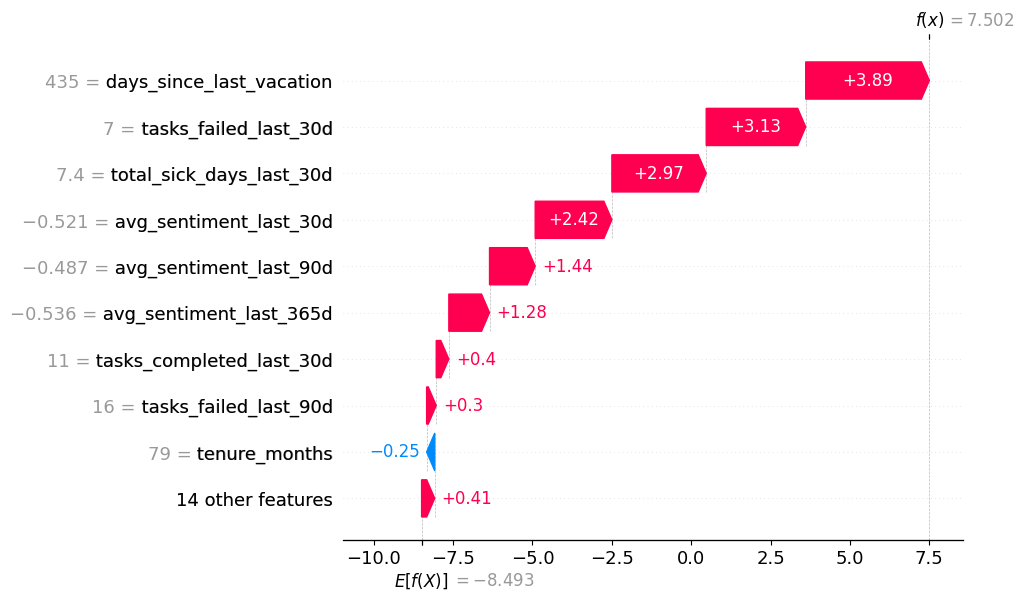

--- Анализ для сотрудника ID: 15712 ---
Вероятность выгорания: 0.00%

Вклад ключевых факторов в предсказание:


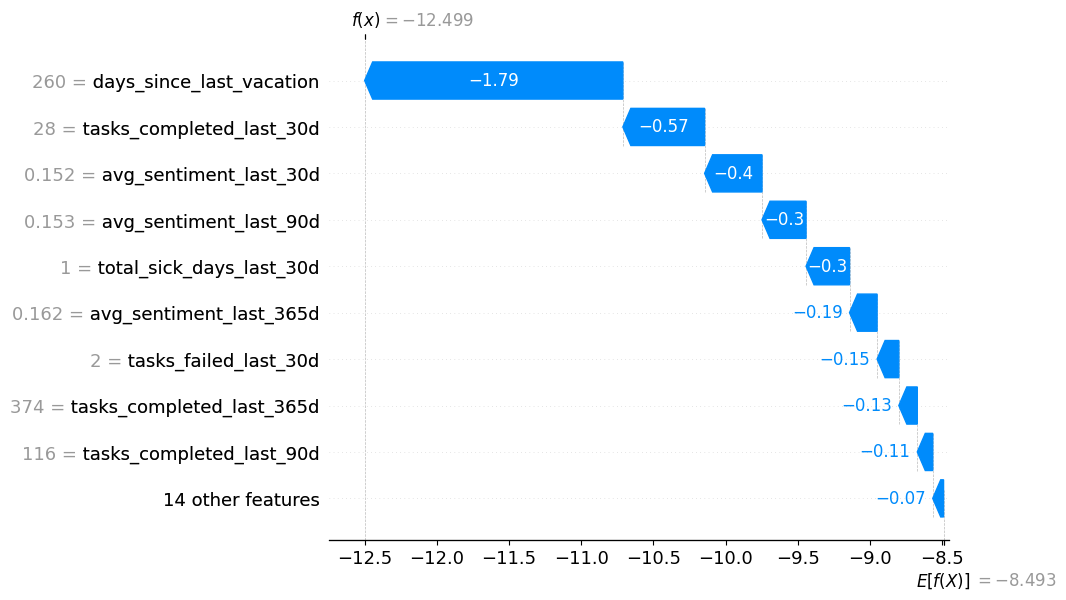

In [13]:
shap.initjs()

explainer = shap.TreeExplainer(model)

def predict_and_explain(employee_data_row):
    if 'employee_id' in employee_data_row.index:
        employee_id = employee_data_row['employee_id']
        features_for_prediction = employee_data_row.drop(['burnout_risk', 'employee_id'])
    else:
        employee_id = "Unknown"
        features_for_prediction = employee_data_row

    prediction_proba = model.predict_proba(features_for_prediction.to_frame().T)[0, 1]
    
    shap_values = explainer.shap_values(features_for_prediction.to_frame().T)
    
    explanation = shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=features_for_prediction,
        feature_names=features_for_prediction.index.tolist()
    )
    
    print(f"--- Анализ для сотрудника ID: {employee_id} ---")
    print(f"Вероятность выгорания: {prediction_proba:.2%}")
    
    print("\nВклад ключевых факторов в предсказание:")
    shap.plots.waterfall(explanation, max_display=10)
    
    return {
        "employee_id": employee_id,
        "burnout_probability": prediction_proba,
        "shap_explanation": explanation
    }


high_risk_employee = df[df['burnout_risk'] == 1].sample(1).iloc[0]
explanation_data = predict_and_explain(high_risk_employee)

low_risk_employee = df[df['burnout_risk'] == 0].sample(1).iloc[0]
explanation_data_low = predict_and_explain(low_risk_employee)

In [14]:
model.save_model("catboost.cbm")